In [3]:

pip install transformers==4.44.0


Loading WikiText-2 dataset from raw URLs...


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


🚀 Starting Training with AGIP + Terminal Attractor (Direct Load)...


Step,Training Loss,Validation Loss
99,No log,1.334913
100,1.771200,No Log
199,1.771200,1.273896
200,1.212100,No Log
299,1.212100,1.261044
300,1.234000,No Log
399,1.234000,1.243614
400,1.420700,No Log
499,1.420700,40.293915
500,1.149600,No Log


[Step 100] Train Loss: 1.7712, Val Loss: 1.3349, Grad: 14.8764
[Step 200] Train Loss: 1.2121, Val Loss: 1.2739, Grad: 6.3430
[Step 300] Train Loss: 1.2340, Val Loss: 1.2610, Grad: 4.9705
[Step 400] Train Loss: 1.4207, Val Loss: 1.2436, Grad: 4.6546

 >>> [Pruning Event] Step 500
     Stats - Loss: 1.1101, Grad: 2.9532 => Rate: 0.266
     Current Sparsity: 20.17% (32863101/162935040)

[Step 500] Train Loss: 1.1496, Val Loss: 40.2939, Grad: 3.1641
[Step 600] Train Loss: 2.7414, Val Loss: 1.4430, Grad: 17.6189
[Step 700] Train Loss: 1.4857, Val Loss: 1.4089, Grad: 3.6501
[Step 800] Train Loss: 1.7396, Val Loss: 1.3858, Grad: 3.7683
[Step 900] Train Loss: 1.4302, Val Loss: 1.3893, Grad: 3.4625

 >>> [Pruning Event] Step 1000
     Stats - Loss: 1.5869, Grad: 3.7309 => Rate: 0.235
     Current Sparsity: 26.47% (43136990/162935040)

[Step 1000] Train Loss: 1.5170, Val Loss: 1.3841, Grad: 3.6692
[Step 1100] Train Loss: 1.6959, Val Loss: 1.3756, Grad: 3.4713
[Step 1200] Train Loss: 1.5373, Val 

✅ Final Test Loss: 1.1737
Saving results and graphs...


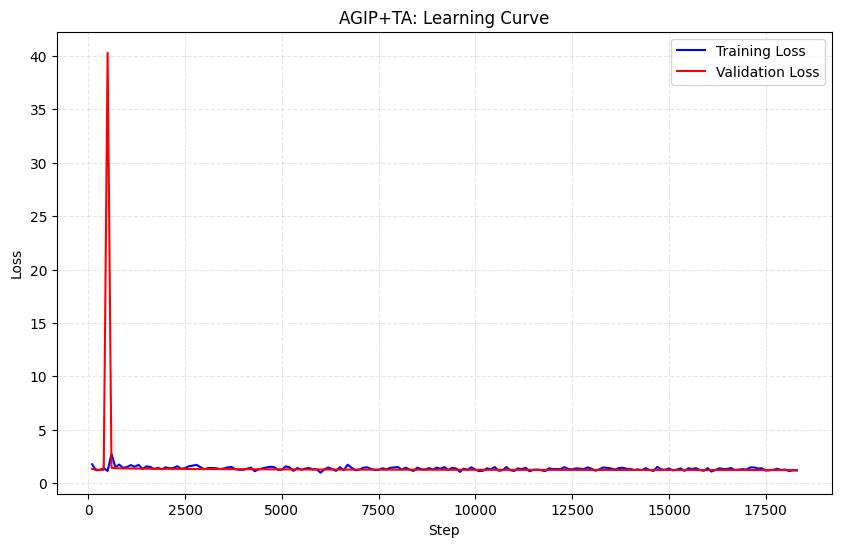

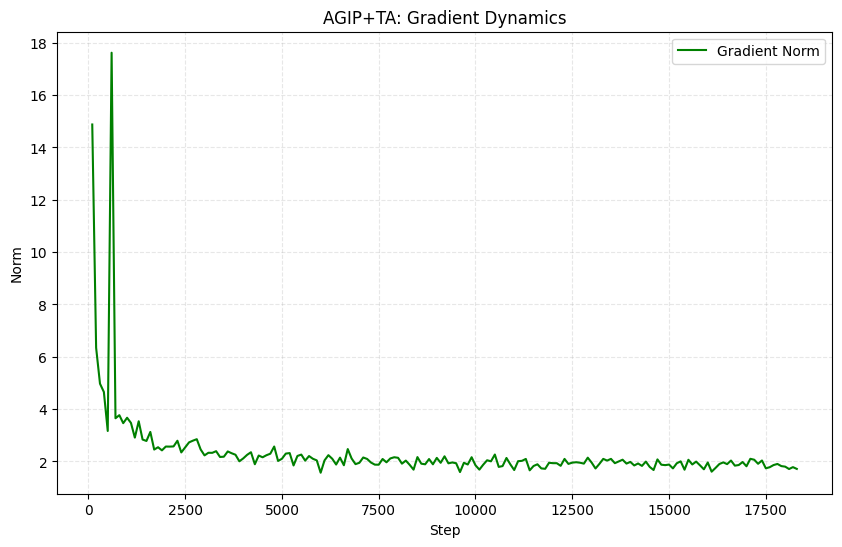

Finalizing model pruning...
✅ All processes completed successfully.


In [4]:
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    Trainer,
    TrainingArguments,
    default_data_collator
)
from transformers.pytorch_utils import Conv1D
from datasets import load_dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# =====================================================
# 1. ヘルパー関数: プルーニング関連
# =====================================================
def is_prunable_module(module):
    """プルーニング対象のレイヤー定義 (LinearとConv1D)"""
    return isinstance(module, (nn.Linear, nn.Conv2d, Conv1D))

def importance_based_pruning(module, prune_rate):
    """勾配重要度 (S = |w * g|) に基づくプルーニング"""
    if hasattr(module, "weight") and module.weight.grad is not None:
        weight = module.weight.data
        grad = module.weight.grad.data
        importance = torch.abs(weight * grad)

        num_params = importance.numel()
        k = int(prune_rate * num_params)
        if k == 0: return

        threshold = torch.topk(importance.view(-1), k, largest=False).values.max()
        mask = (importance > threshold).float()
        prune.CustomFromMask.apply(module, "weight", mask)

# =====================================================
# 2. カスタムTrainer: AGIPとTAの実装
# =====================================================
class AGIP_TA_Trainer(Trainer):
    def __init__(self, *args, ta_alpha=1.0, ta_beta=0.5, base_prune_rate=0.1, prune_interval=500, **kwargs):
        super().__init__(*args, **kwargs)
        self.ta_alpha = ta_alpha
        self.ta_beta = ta_beta
        self.epsilon = 1e-8
        self.base_prune_rate = base_prune_rate
        self.prune_interval = prune_interval

        self.global_step_counter = 0
        self.history = []
        self.loss_buffer = []
        self.grad_buffer = []
        self.loss_window = []
        self.grad_norm_window = []

    def training_step(self, model, inputs):
        model.train()
        inputs = self._prepare_inputs(inputs)

        # 1. Forward & Loss
        with self.compute_loss_context_manager():
            loss = self.compute_loss(model, inputs)

        # 2. Backward
        if self.args.n_gpu > 1:
            loss = loss.mean()
        loss.backward()

        # Phase 2: TA更新則の準備
        E = loss.detach().item()
        grad_norm_sq = 0.0
        for p in model.parameters():
            if p.grad is not None:
                grad_norm_sq += p.grad.data.norm(2).item() ** 2
        grad_norm = grad_norm_sq ** 0.5

        self.loss_buffer.append(E)
        self.grad_buffer.append(grad_norm)
        self.loss_window.append(E)
        self.grad_norm_window.append(grad_norm)

        self.global_step_counter += 1

        # TA係数計算
        if grad_norm > 0:
            ta_factor = (E ** self.ta_beta) / (grad_norm ** 2 + self.epsilon)
            ta_factor = min(ta_factor, 10.0)
        else:
            ta_factor = 0.0

        optimizer = self.optimizer

        # 【重要】安全装置（クリッピング）
        if self.args.max_grad_norm is not None and self.args.max_grad_norm > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), self.args.max_grad_norm)

        # C-1. AdamW更新
        optimizer.step()

        # C-2. TA項による追加更新
        if ta_factor > 0:
            current_lr = optimizer.param_groups[0]['lr']
            with torch.no_grad():
                for p in model.parameters():
                    if p.grad is not None:
                        ta_update = current_lr * self.ta_alpha * ta_factor * p.grad
                        p.data -= ta_update

        # Phase 1: 動的プルーニング (zero_gradの前に実行)
        if self.global_step_counter % self.prune_interval == 0:
            self.dynamic_pruning(model)

        # 勾配リセット
        optimizer.zero_grad()

        # ログ出力 (100ステップごと)
        if self.global_step_counter % 100 == 0:
            avg_loss = np.mean(self.loss_buffer)
            avg_grad = np.mean(self.grad_buffer)
            self.loss_buffer = []
            self.grad_buffer = []

            val_metrics = self.evaluate(eval_dataset=self.eval_dataset)
            val_loss = val_metrics['eval_loss']
            self.model.train()

            self.history.append({
                "step": self.global_step_counter,
                "train_loss": avg_loss,
                "val_loss": val_loss,
                "grad_norm": avg_grad
            })
            print(f"[Step {self.global_step_counter}] Train Loss: {avg_loss:.4f}, Val Loss: {val_loss:.4f}, Grad: {avg_grad:.4f}")

        return loss.detach()

    def dynamic_pruning(self, model):
        avg_loss = np.mean(self.loss_window[-50:]) if self.loss_window else 0
        avg_grad = np.mean(self.grad_norm_window[-50:]) if self.grad_norm_window else 0

        if avg_loss > 0:
            prune_rate = self.base_prune_rate * (avg_grad / (avg_loss + 1e-6))
        else:
            prune_rate = self.base_prune_rate

        prune_rate = min(max(prune_rate, 0.01), 0.3)

        print(f"\n >>> [Pruning Event] Step {self.global_step_counter}")
        print(f"     Stats - Loss: {avg_loss:.4f}, Grad: {avg_grad:.4f} => Rate: {prune_rate:.3f}")

        for _, module in model.named_modules():
            if is_prunable_module(module):
                if hasattr(module, "weight_mask"):
                    prune.remove(module, "weight")
                importance_based_pruning(module, prune_rate)

        total_params = 0
        zero_params = 0
        for _, module in model.named_modules():
            if hasattr(module, "weight"):
                total_params += module.weight.nelement()
                zero_params += torch.sum(module.weight == 0).item()

        sparsity = zero_params / total_params if total_params > 0 else 0
        print(f"     Current Sparsity: {sparsity*100:.2f}% ({zero_params}/{total_params})\n")

# =====================================================
# 3. メイン実行部
# =====================================================
def main():
    # 【修正】WikiText-2のRawデータを直接URLから読み込む (404エラー回避策)
    print("Loading WikiText-2 dataset from raw URLs...")
    data_urls = {
        "train": "https://raw.githubusercontent.com/pytorch/examples/master/word_language_model/data/wikitext-2/train.txt",
        "validation": "https://raw.githubusercontent.com/pytorch/examples/master/word_language_model/data/wikitext-2/valid.txt",
        "test": "https://raw.githubusercontent.com/pytorch/examples/master/word_language_model/data/wikitext-2/test.txt"
    }
    raw_datasets = load_dataset("text", data_files=data_urls)

    tokenizer = AutoTokenizer.from_pretrained("gpt2")
    tokenizer.pad_token = tokenizer.eos_token

    def tokenize_function(examples):
        return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

    tokenized_datasets = raw_datasets.map(tokenize_function, batched=True, remove_columns=["text"])
    tokenized_datasets = tokenized_datasets.map(
        lambda batch: {"labels": batch["input_ids"]}, batched=True
    )
    tokenized_datasets.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

    print("Loading GPT-2 Model...")
    model = AutoModelForCausalLM.from_pretrained("gpt2")
    model.resize_token_embeddings(len(tokenizer))

    output_dir = "./results_agip_ta_final"
    training_args = TrainingArguments(
        output_dir=output_dir,
        evaluation_strategy="no",
        per_device_train_batch_size=2,
        per_device_eval_batch_size=4,
        learning_rate=5e-5,
        num_train_epochs=1,
        weight_decay=0.01,
        logging_steps=100,
        save_strategy="no",
        report_to="none",
        dataloader_num_workers=2,
        max_grad_norm=4.0 # 安全装置
    )

    trainer = AGIP_TA_Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        tokenizer=tokenizer,
        data_collator=default_data_collator,
        ta_alpha=1.0,
        ta_beta=0.5,
        base_prune_rate=0.1,
        prune_interval=500
    )

    print("🚀 Starting Training with AGIP + Terminal Attractor (Direct Load)...")
    trainer.train()

    print("\n🔍 Evaluating on Test Set...")
    test_results = trainer.evaluate(tokenized_datasets["test"])
    final_test_loss = test_results['eval_loss']
    print(f"✅ Final Test Loss: {final_test_loss:.4f}")

    print("Saving results and graphs...")
    df_log = pd.DataFrame(trainer.history)
    df_log.to_csv("agip_ta_log_final.csv", index=False)

    if not df_log.empty:
        plt.figure(figsize=(10, 6))
        plt.plot(df_log['step'], df_log['train_loss'], label='Training Loss', color='blue')
        plt.plot(df_log['step'], df_log['val_loss'], label='Validation Loss', color='red')
        plt.xlabel('Step')
        plt.ylabel('Loss')
        plt.title('AGIP+TA: Learning Curve')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.3)
        plt.savefig('agip_ta_loss_curve.png')
        plt.show()
        plt.close()

        plt.figure(figsize=(10, 6))
        plt.plot(df_log['step'], df_log['grad_norm'], label='Gradient Norm', color='green')
        plt.xlabel('Step')
        plt.ylabel('Norm')
        plt.title('AGIP+TA: Gradient Dynamics')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.3)
        plt.savefig('agip_ta_grad_norm.png')
        plt.show()
        plt.close()

    print("Finalizing model pruning...")
    for name, module in model.named_modules():
        if is_prunable_module(module) and hasattr(module, "weight_mask"):
            prune.remove(module, "weight")

    model.save_pretrained("./final_gpt2_agip_ta")
    print("✅ All processes completed successfully.")

if __name__ == "__main__":
    main()